# BINF 4002 — Machine Learning for Biomedical Data
## Homework Assignment: End-to-End ML Across Biomedical Domains

**Total Points: 100** (select any **two** of the three problems for grading; the third is optional bonus worth up to 10 extra-credit points)

| Problem | Domain | Points |
|---------|--------|--------|
| **Problem 1** | Biology — Pan-Cancer Gene Expression Classification | 50 |
| **Problem 2** | Clinical/EHR — Preventive Screening Compliance Prediction | 50 |
| **Problem 3** | Public Health — Influenza Forecasting | 50 |

### Instructions
1. **Choose two** problems to submit for grading.
2. You may complete the third for **up to 10 bonus points**.
3. All code must run **end-to-end in Google Colab**.
4. You are **encouraged** to use GenAI tools (Gemini, ChatGPT, Claude, Copilot) to understand concepts, debug, and implement. However, you must:
   - Understand and be able to explain every line of your code.
   - Write all discussion answers in your own words with genuine analytical depth.
   - **Submit a link to your primary GenAI conversation(s)** used during this assignment (e.g., a shared ChatGPT/Claude conversation link). This is for transparency, not penalization.
6. Submit this notebook as a `.ipynb` file with all cells executed and outputs visible.

### What we expect

Beyond working code and results, we expect you to think out loud throughout your notebook. In the problems below, comment on your model's performance across all relevant axes: not just a single number.

- What concerns would you have about adapting these results to a real-world setting?
- How would you extend your approach given more time or data, and what barriers would you expect?
- What trade-offs exist in your design choices, and why did you resolve them the way you did?

A notebook that achieves modest results but demonstrates genuine understanding will score higher than one with strong numbers and no interpretation.

In [ ]:
# ============================================================
# PASTE YOUR GenAI CONVERSATION LINK(S) HERE
# ============================================================
GENAI_LINKS = [
    # "https://chatgpt.com/share/...",
    # "https://claude.ai/share/...",
]


---
## Environment Setup (Run First)


In [2]:
# ============================================================
# SHARED DEPENDENCIES — run this cell once
# ============================================================
!pip install -q scikit-learn pandas numpy matplotlib seaborn umap-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score, train_test_split, GridSearchCV
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
    mean_absolute_error, mean_squared_error
)
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

print("✅ All shared dependencies loaded.")


✅ All shared dependencies loaded.


---
---
# Problem 1: Pan-Cancer Gene Expression Classification

## Background
RNA sequencing (RNA-Seq) measures the expression levels of thousands of genes simultaneously, producing a molecular "fingerprint" of a tissue sample. Different cancer types originate from different tissues and harbor distinct transcriptomic programs. In this problem, you will build a classifier that predicts cancer type from gene expression profiles, exploring how dimensionality reduction affects performance in a high-dimensional, low-sample-size (p >> n) setting.

## Dataset
The **UCI ML Gene Expression Cancer RNA-Seq** dataset contains 801 samples across 5 cancer types (BRCA, KIRC, LUAD, PRAD, COAD) with 20,531 gene expression features (RSEM normalized counts).

## Learning Objectives
- Handle extreme high-dimensionality (p >> n)
- Compare dimensionality reduction strategies
- Perform stratified cross-validation with class imbalance
- Interpret model outputs in biological context

---


## 1.1 Dataset Loading & Initial Inspection (5 pts)

In [3]:
# ============================================================
# 1.1 LOAD THE DATASET
# ============================================================
# Download the TCGA PANCAN RNA-Seq dataset (801 samples, 20531 genes, 5 cancer types)
# Source: UCI ML Repository — direct archive download

import os, tarfile, glob, shutil

DATA_DIR = '/content/pancan_data'
os.makedirs(DATA_DIR, exist_ok=True)

data_csv = os.path.join(DATA_DIR, 'data.csv')
labels_csv = os.path.join(DATA_DIR, 'labels.csv')

if not os.path.exists(data_csv):
    print("📥 Downloading TCGA PANCAN dataset...")

    # Primary source: UCI archive
    !wget -q --show-progress \
        "https://web.archive.org/web/20250330202645id_/https://archive.ics.uci.edu/ml/machine-learning-databases/00401/TCGA-PANCAN-HiSeq-801x20531.tar.gz" \
        -O /content/pancan.tar.gz

    # Extract (the tar.gz contains a nested structure)
    print("📦 Extracting...")
    with tarfile.open('/content/pancan.tar.gz', 'r:gz') as outer:
        outer.extractall('/content/pancan_tmp')

    # Handle nested tar files
    for t in glob.glob('/content/pancan_tmp/**/*.tar', recursive=True):
        with tarfile.open(t, 'r') as inner:
            inner.extractall(DATA_DIR)

    # Also move any CSVs found at top level
    for f in glob.glob('/content/pancan_tmp/**/*.csv', recursive=True):
        shutil.copy(f, DATA_DIR)

    # Verify extraction worked
    found = os.listdir(DATA_DIR)
    print(f"  Extracted: {found}")

    if not os.path.exists(data_csv):
        # Try to find the files with any name
        csvs = [f for f in found if f.endswith('.csv')]
        for f in csvs:
            fp = os.path.join(DATA_DIR, f)
            # data file is large (~70MB), labels is small
            size = os.path.getsize(fp) / 1e6
            if size > 10:
                shutil.copy(fp, data_csv)
                print(f"  Mapped {f} ({size:.0f}MB) → data.csv")
            else:
                shutil.copy(fp, labels_csv)
                print(f"  Mapped {f} ({size:.2f}MB) → labels.csv")

    assert os.path.exists(data_csv), (
        "❌ data.csv not found after extraction. "
        "Please download manually from:\n"
        "https://archive.ics.uci.edu/dataset/401/gene+expression+cancer+rna+seq\n"
        "and upload data.csv + labels.csv to /content/pancan_data/"
    )
    print("✅ Download complete!")
else:
    print("✅ Dataset already downloaded.")

# --- Load ---
X_raw = pd.read_csv(data_csv, index_col=0)
y_series = pd.read_csv(labels_csv, index_col=0)
y_raw = y_series.iloc[:, 0]

print(f"\nFeature matrix shape: {X_raw.shape}")
print(f"Target distribution:\n{y_raw.value_counts()}")
print(f"\nFirst 5 gene columns: {list(X_raw.columns[:5])}")
print(f"Any missing values in X: {X_raw.isnull().any().any()}")
print(f"Any missing values in y: {y_raw.isnull().any()}")


✅ Dataset already downloaded.

Feature matrix shape: (801, 20531)
Target distribution:
Class
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
Name: count, dtype: int64

First 5 gene columns: ['gene_0', 'gene_1', 'gene_2', 'gene_3', 'gene_4']
Any missing values in X: False
Any missing values in y: False


#### Conceptual Question 1.1

**Q: This dataset has 20,531 features but only 801 samples. Explain in your own words:**
1. **Why is this "p >> n" setting problematic for standard ML algorithms?**
2. **Name two distinct strategies for addressing this problem** and briefly explain how they differ conceptually.

---


## 1.2 Problem statement (45 pts)


Build a classifier that predicts cancer type from gene expression profiles.

This dataset has far more features than samples. Your solution should demonstrate that you understand why this matters and how it shapes every downstream decision: from preprocessing through model selection to interpretation. We expect you to explore how aggressively you can compress the feature space before classification degrades, compare at least two modeling approaches, and critically assess your results: classification accuracy on this dataset will likely be very high, and part of your job is to reason about whether that reflects genuine diagnostic power or properties of the dataset itself.

We expect executable code, quality figures, and written explanations that connect your technical choices to the biology and the data structure. Results without justification, or justification without results, will receive partial credit.



---
---
# Problem 2: Predicting Preventive Screening Non-Compliance (Synthea)

## Background
Preventive screenings (colonoscopy, mammography, pap test) are evidence-based interventions recommended by the U.S. Preventive Services Task Force (USPSTF). Despite clear guidelines, many patients fall behind on recommended screenings. Health systems want to **proactively identify patients likely to remain non-compliant** so they can target outreach interventions.

In this problem, you will:
1. **Encode clinical guidelines as logic** to determine screening eligibility and compliance status.
2. **Construct a time-sensitive prediction label** (will this patient remain non-compliant at 12 months?).
3. **Build a classifier** using encounter history, demographics, and prior compliance patterns.

## Dataset
**Synthea** — a synthetic patient generator that produces realistic (but artificial) EHR data. We will use a pre-generated 3,000-patient dataset.

## Key Challenge
This problem requires you to think like a clinical informaticist: you must **define the clinical rules** before you can do any ML. The hardest part isn't the model — it's the label construction and feature engineering.

---


## 2.1 Dataset Loading & Initial Inspection (5 pts)

In [3]:
# ============================================================
# 2.1 LOAD SYNTHEA DATA
# ============================================================
# Synthea generates synthetic EHR data. Generating 3,000 patients
# takes ~10+ minutes on Colab, so we provide pre-generated CSVs.

import os

# === Download pre-generated Synthea data ===
SYNTHEA_DRIVE_URL = "142NYfjgHSSaf8yTx3RgOixfl4G3l8sAs"  # Instructor: replace before distributing

csv_dir = '/content/synthea_csv'
os.makedirs(csv_dir, exist_ok=True)

# Check if data already exists
if not os.path.exists(f'{csv_dir}/patients.csv'):
    print("📥 Downloading pre-generated Synthea data...")
    # Instructor will provide a Google Drive folder with the CSVs
    # Students: if the download link doesn't work, generate data with Option B below
    try:
        # Try gdown for Google Drive
        !pip install -q gdown
        import gdown
        gdown.download_folder(
            f"https://drive.google.com/drive/folders/{SYNTHEA_DRIVE_URL}",
            output=csv_dir, quiet=False
        )
        print("✅ Download complete!")
    except Exception as e:
        print(f"⚠️ Google Drive download failed: {e}")
else:
    print("✅ Synthea data already exists.")

# List files
for f in sorted(os.listdir(csv_dir)):
    size_mb = os.path.getsize(f'{csv_dir}/{f}') / 1e6
    print(f"  {f:40s} {size_mb:8.2f} MB")


✅ Synthea data already exists.
  conditions.csv                              13.70 MB
  encounters.csv                              51.89 MB
  observations.csv                           306.72 MB
  patients.csv                                 0.90 MB
  procedures.csv                              89.12 MB


In [4]:
# ============================================================
# 2.1b LOAD KEY TABLES
# ============================================================

import pandas as pd

patients = pd.read_csv(f'{csv_dir}/patients.csv')
encounters = pd.read_csv(f'{csv_dir}/encounters.csv')
conditions = pd.read_csv(f'{csv_dir}/conditions.csv')
procedures = pd.read_csv(f'{csv_dir}/procedures.csv')
observations = pd.read_csv(f'{csv_dir}/observations.csv')

# Parse dates — Synthea uses START/STOP, not DATE, for most tables
# Strip timezone info to avoid UTC comparison issues
patients['BIRTHDATE'] = pd.to_datetime(patients['BIRTHDATE'], errors='coerce')
patients['DEATHDATE'] = pd.to_datetime(patients['DEATHDATE'], errors='coerce')

# Use utc=True then strip tz for consistent naive timestamps
for df, date_cols in [
    (encounters, ['START', 'STOP']),
    (conditions, ['START', 'STOP']),
    (procedures, ['START', 'STOP']),
    (observations, ['DATE']),
]:
    for col in date_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], utc=True, errors='coerce').dt.tz_localize(None)

print(f"Patients:     {patients.shape}")
print(f"Encounters:   {encounters.shape}")
print(f"Conditions:   {conditions.shape}")
print(f"Procedures:   {procedures.shape}")
print(f"Observations: {observations.shape}")

print(f"\nGender distribution:\n{patients['GENDER'].value_counts()}")
print(f"\nAge range: {patients['BIRTHDATE'].min().date()} to {patients['BIRTHDATE'].max().date()}")


Patients:     (3000, 28)
Encounters:   (155309, 15)
Conditions:   (95009, 7)
Procedures:   (422270, 10)
Observations: (1757281, 9)

Gender distribution:
GENDER
F    1563
M    1437
Name: count, dtype: int64

Age range: 1916-04-09 to 2026-04-03


### Conceptual Question 2.1

**Q:** Before writing any ML code, answer:
1. **Look up the current USPSTF guidelines with "A" or "B" recommandations.** For each of the following screenings, state: (a) the recommended **starting age**, (b) the recommended **screening frequency**, and (c) any **eligibility criteria** (sex, conditions):
   - Colorectal cancer screening (colonoscopy)
   - Breast cancer screening (mammography)
   - Cervical Cancer (cervical cytology alone)
   
   You will need this information to build the screening rule configurations in the next section.

2. **What does "non-compliance" mean in this context?** Why is the distinction between "never eligible" and "eligible but non-compliant" critical for correct label construction?

3. **Synthea generates data using clinical modules that often follow guidelines deterministically.** How might this affect the difficulty and realism of your prediction task?

---


### Answer

1. USPSTF A and B recommendations

    **Colorectal cancer** -- screening with colonoscopy is one acceptable strategy amonng several (e.g. FIT, sDNA-FIT)
      - Starting age: 45 years (screening is offered from 45 through 75).
      - Frequency: depends on the test. Colonoscopy every 10 years is the standard (since Synthea dataset mostly encodes colonoscopies)
      - Level of evidence: Grade B for ages 45–49; A for ages 50–75.
      - Eligibility: Adults at "average risk"" of colorectal cancer. applies to men and women. We'll **exclude** high-risk patients/syndromes such as personal history of CRC, IBD, Lynch syndrome, FAP, prior adenomatous polyps, as those outside "average risk" will need different screening recommendations.

    **Breast cancer** -- screening with mammography (Fun fact: In Asian countries like Thailand, ultrasonography is often used as a supplement to mammography because women tend to have denser breast tissue, which can make mammography less sensitive).
      - Starting age: 40 years through 74 years
      - Frequency: Every 2 years (biennial)
      - Level of evidence: Grade B for ages 40-74
      - Eligibility: Cisgender women and other invidiuals assigned female who are at average risk; this appplies to those even with certain risk factors (e.g. family history of breast cancer, dense breasts), but not to very high-risk situations. **Exclusions** include prior breast cancer, BRCA1/BRCA2 carriers, prior chest radiation at young age, high-risk breast lesions on biopsy.

    **Cervical cancer** -- cervical cytology alone (Pap smear)
      - Starting age: 21 years (not before 21). Stopping at 65 (no routine screening after 65)
      - Frequency: Every 3 years with cytology alone
      - Level of evidence: A
      - Eligibility: Persons with a cervix (framed around women in the evidence); not for <21; not routine after 65 with adequate prior negative screening; **Exclusions** include those s/p hysterectomy with cervix removal (for benigh lesions) without a continued indication to screen, prior high-grade cervical lesion or cervical cancer, immunocompromised (HIV), in utero DES exposure

2. What "non-compliance" means here, and never eligible vs eligible but non-compliant
    - A patient is "compliant" with a screening if they have had the recommended test within the recommended interval, given they are someone the guideline applies to
    - Non-compliance usually means that the patient **meet guideline criteria to be screened** (right age/sex/risk and not excluded) but **has not completed** the recommended test within the recommended interval (or at all when due).
    - Never eligible: the patients are outside the guideline denominator (e.g. wrong age, no cervix, already met stop screening criteria). They should not count as "failed to comply" with a screening program, because no screening was indicated.
    - Why it matters! if we label everyone with a recent test as "non-compliant", we mix people who were not supposed to be screened with people who were supposed to be screened but missed care. This dilutes or reverses the causal/clinical meaning of the label, and makes models learn **eligibility** instead of **underscreen among eligible patients**.

3. Synthea and deterministic guideline-following

    Synthetic builds timelines with guideline-style modules, so the outcome we treat as "ground truth" is **NOT INDEPENDENT** of the eligibility and interval rules we use to define compliance in the first place--basically, it is partly the **same logic**. Additionally, non-compliance in Synthea shows up mostly as stochastic or module noise, whereas in real care it is shaped by **social determinants, access, continuity with a usual source of care, and how patients experience the health system**--dimensions Synthea does not model.

    We also expect strong model metrics. And good performance on Synthea will likely overstate how well the model would work on real EHRs. Feature importance from Synthea might not transfer. Variables that rise to the top can be almost circular with the label rather than drivers of underuse in practice. The patient who are hardest for real outreach--for example, people who are otherwise well connected to care but still not screened--are underrepresented relative to real populations.

    So synthea is best used to validate the pipeline, not to prove that the model captures clinically actionable non-compliance. External validation on a real EHR, or at least a more realistic simulator like MIMIC, would be needed before deploying.



## 2.2 Problem statement (45 pts)


Build a classifier that predicts which patients will remain non-compliant with preventive screenings 12 months from now.

This problem requires clinical reasoning before any modeling: you need to translate screening guidelines into computable rules, construct labels that reflect a meaningful clinical question, and engineer features from multiple EHR tables; all while respecting a temporal prediction boundary. The modeling itself is standard once those pieces are right. Be deliberate about how you split the data (the same patient can appear across multiple screening contexts), and about what your model actually learns: including whether its strongest signals would survive contact with real-world EHR data, where non-compliance is driven by factors Synthea cannot simulate.

We expect executable code, figures, and written explanations. We also consider pipeline efficiency (runtime and memory) given the dataset scale.

### Exploratory Data Analysis & Playing Around

In [5]:
# ============================================================
# THIS IS UNRELATED TO THE QUESTION, IT'S JUST FOR ME TO PERFORM EDA
# SEE ANSWERS IN THE CELLS BELOW
# ============================================================
# Check the date range of actual clinical events (not birthdays)
print("Encounter date range:")
print(f"  earliest: {encounters['START'].min()}")
print(f"  latest:   {encounters['START'].max()}")

print("\nProcedure date range:")
print(f"  earliest: {procedures['START'].min()}")
print(f"  latest:   {procedures['START'].max()}")

procedures[procedures['DESCRIPTION'].str.contains('colonoscopy', case=False, na=False)]
patients.head()

# ============================================================
# DIAGNOSTIC: what procedure descriptions exist in Synthea?
# ============================================================

# All unique procedure descriptions, sorted by how common they are
desc_counts = procedures['DESCRIPTION'].value_counts()
print(f"Total unique procedure descriptions: {len(desc_counts)}\n")

# 1. Everything colonoscopy-ish
print("=== Colonoscopy-related ===")
print(desc_counts[desc_counts.index.str.contains('colon|sigmoid|fecal|occult|fit', case=False, na=False)])

# 2. Everything breast / mammography-ish
print("\n=== Mammography / breast-related ===")
print(desc_counts[desc_counts.index.str.contains('mammo|breast', case=False, na=False)])

# 3. Everything cervical / Pap-ish
print("\n=== Cervical / Pap-related ===")
print(desc_counts[desc_counts.index.str.contains('pap|cervi|smear|cytolog|cytopathology', case=False, na=False)])


Encounter date range:
  earliest: 1920-06-15 07:40:39
  latest:   2026-04-06 04:19:47

Procedure date range:
  earliest: 1936-09-15 00:01:14
  latest:   2026-04-05 03:42:56
Total unique procedure descriptions: 361

=== Colonoscopy-related ===
DESCRIPTION
Colonoscopy (procedure)                            1286
Fitting of denture (procedure)                      380
Screening for occult blood in feces (procedure)     142
Partial resection of colon (procedure)               23
Biopsy of colon (procedure)                          20
Name: count, dtype: int64

=== Mammography / breast-related ===
DESCRIPTION
Mammography (procedure)                             289
Biopsy of breast (procedure)                         23
Ultrasonography of bilateral breasts (procedure)     21
Mammogram - symptomatic (procedure)                  13
Lumpectomy of breast (procedure)                     12
Excision of lesion of breast (procedure)             10
Screening mammography (procedure)                    

### Cohort Construction: eligibility, compliance at T, 12m label

In [14]:
# ============================================================
# 2.2 Cohort construction: eligibility, compliance at T, 12m label
# ============================================================
# Clinical question: "of patients overdue today, who will still be overdue
# in 12 months?" 
# So the row-level unit is a (patient, screening) pair that is:
#     (a) eligible per USPSTF at index date T, AND
#     (b) currently non-compliant at T.
# Label = 1 if the patient has NO qualifying screening procedure in
# (T, T+12m]; = 0 if they got screened in that window.
#
# Temporal boundary: every feature uses only events with START < T.
# The window (T, T+12m] is outcome-only, never a feature.
#
# Why one row per (patient, screening): a 55-year-old woman can be
# eligible for colorectal + breast + cervical simultaneously = up to
# 3 rows. Downstream CV MUST group-split by PATIENT; otherwise her
# demographics & utilization leak across folds.
#
# Here I use a single index date (vs. a sliding window): simpler, cheaper,
# and avoids tricky within-patient longitudinal leakage. Cost: fewer
# training examples and no temporal drift check. Noted in discussion.
# ------------------------------------------------------------------------

INDEX_DATE = pd.Timestamp('2025-01-01') # still having full 12-month label window
HORIZON    = pd.DateOffset(months=12)

# USPSTF rules encoded from the answer to 2.1.
# `proc_patterns` are case-insensitive substrings matched against
# Synthea's DESCRIPTION column (more robust than hardcoding SNOMED
# codes across versions).
SCREENINGS = {
    'colorectal': dict(
        min_age=45, max_age=75, interval_years=10, sex=None,
        proc_patterns=['colonoscopy'], # make sure to match the procedure description
        # Note: in a more complete implementation, we would also include FIT
        # with a 1-year interval. Keeping colonoscopy-only here for simplicity.
        excl=['malignant neoplasm of colon', 'colon cancer',
              'crohn', 'ulcerative colitis',
              'familial adenomatous polyposis']),
    'breast': dict(
        min_age=40, max_age=74, interval_years=2, sex='F',
        # only screening mammography counts; diagnostic "symptomatic" mammograms are workup, not screening
        proc_patterns=['mammography', 'screening mammography'],
        excl=['malignant neoplasm of breast', 'breast cancer']),
    'cervical': dict(
        min_age=21, max_age=65, interval_years=3, sex='F',
        # Synthea encodes Pap smears as "Cytopathology procedure
        # preparation of smear genital source" — match on that.
        proc_patterns=['cytopathology'], # matches "Cytopathology procedure preparation of smear genital source"
        excl=['malignant neoplasm of cervix', 'cervical cancer',
              'hysterectomy']),
}

# Lowercase description columns once for fast substring matching.
procedures['_desc'] = procedures['DESCRIPTION'].str.lower().fillna('')
conditions['_desc'] = conditions['DESCRIPTION'].str.lower().fillna('')

def match_any(series, patterns):
    """Any-of substring match, case-insensitive (series already lower)."""
    m = pd.Series(False, index=series.index)
    for p in patterns:
        m |= series.str.contains(p, na=False)
    return m

patients['age_at_T']   = (INDEX_DATE - patients['BIRTHDATE']).dt.days / 365.25 # Add age column
patients['alive_at_T'] = patients['DEATHDATE'].isna() | (patients['DEATHDATE'] > INDEX_DATE) # Add alive column

rows = []
for name, cfg in SCREENINGS.items():
    # (1) Demographic eligibility (alive, age window, sex).
    elig = patients['alive_at_T'] & \
           patients['age_at_T'].between(cfg['min_age'], cfg['max_age'])
    if cfg['sex'] is not None:
        elig &= patients['GENDER'].eq(cfg['sex'])

    # (2) Exclude high-risk / contraindicated via pre-T conditions.
    excl_mask = match_any(conditions['_desc'], cfg['excl']) & \
                (conditions['START'] < INDEX_DATE)
    excl_pts  = conditions.loc[excl_mask, 'PATIENT'].unique()
    elig &= ~patients['Id'].isin(excl_pts)

    # (3) Screening procedures of this type.
    sp = procedures.loc[match_any(procedures['_desc'], cfg['proc_patterns']),
                        ['PATIENT', 'START']]
    last_pre = sp[sp['START'] < INDEX_DATE].groupby('PATIENT')['START'].max()
    got_post = sp[(sp['START'] >  INDEX_DATE) &
                  (sp['START'] <= INDEX_DATE + HORIZON)]['PATIENT'].unique()

    sub = patients.loc[elig, ['Id','GENDER','RACE','ETHNICITY','age_at_T']].copy()
    sub['screening']          = name
    sub['last_screen_pre_T']  = sub['Id'].map(last_pre)
    sub['years_since_screen'] = (INDEX_DATE - sub['last_screen_pre_T']).dt.days / 365.25

    # Compliant at T = screened within recommended interval before T.
    sub['compliant_at_T'] = sub['years_since_screen'].le(cfg['interval_years']).fillna(False)

    # Restrict to currently non-compliant (the outreach denominator).
    sub = sub[~sub['compliant_at_T']].copy()

    # Label: 1 = still non-compliant at T+12m (did not screen in the window).
    sub['label'] = (~sub['Id'].isin(got_post)).astype(int)
    rows.append(sub)

cohort = pd.concat(rows, ignore_index=True)

# How many of each screening procedure happened in the label window (T, T+12m]?
window = (procedures['START'] > INDEX_DATE) & (procedures['START'] <= INDEX_DATE + HORIZON)

for name, cfg in SCREENINGS.items():
    pat_mask = match_any(procedures['_desc'], cfg['proc_patterns'])
    n_in_window = (window & pat_mask).sum()
    print(f"{name:12s}: {n_in_window} procedures in (T, T+12m]")

print(f"Cohort rows (eligible & currently non-compliant): {len(cohort)}")
print(f"Unique patients:                                  {cohort['Id'].nunique()}")
print(f"\nRows by screening:\n{cohort['screening'].value_counts()}")
print(f"\nLabel prevalence by screening (1 = remains non-compliant):")
print(cohort.groupby('screening')['label'].agg(['mean','count']).round(3))


colorectal  : 113 procedures in (T, T+12m]
breast      : 32 procedures in (T, T+12m]
cervical    : 96 procedures in (T, T+12m]
Cohort rows (eligible & currently non-compliant): 1536
Unique patients:                                  926

Rows by screening:
screening
cervical      621
breast        514
colorectal    401
Name: count, dtype: int64

Label prevalence by screening (1 = remains non-compliant):
             mean  count
screening               
breast      1.000    514
cervical    0.934    621
colorectal  0.915    401


In [15]:
# Who got the 32 mammograms in the label window?
mammo_window = procedures[
    (procedures['START'] > INDEX_DATE) &
    (procedures['START'] <= INDEX_DATE + HORIZON) &
    match_any(procedures['_desc'], SCREENINGS['breast']['proc_patterns'])
]

# Were these patients compliant or non-compliant at T?
# (patients['Id'] isin mammo_window patient list, cross-ref with cohort)
mammo_pts = set(mammo_window['PATIENT'].unique())
cohort_breast = cohort[cohort['screening'] == 'breast']
overlap = cohort_breast[cohort_breast['Id'].isin(mammo_pts)]
print(f"Mammograms in window: {len(mammo_window)}")
print(f"Unique patients: {len(mammo_pts)}")
print(f"Overlap with non-compliant breast cohort: {len(overlap)}")

Mammograms in window: 32
Unique patients: 31
Overlap with non-compliant breast cohort: 0


Synthea's breast cancer module did not generate any re-screening events for previously non-compliant women during the 12-month label window. This is itself a finding about the simulator's behavior. Rather than train a model on a degenerate single-class label, I excluded breast from modeling and retained it only for descriptive purposes.

In [16]:
# ------------------------------------------------------------------------
# Drop breast: Synthea's breast module produced zero re-screens for
# previously non-compliant women in the 12-month window, so the label
# is degenerate (single class). We retain this finding for the discussion.
# ------------------------------------------------------------------------
print(f"\nBefore dropping degenerate labels:")
print(cohort.groupby('screening')['label'].agg(['mean', 'count']).round(3))

# Drop any screening whose label has zero variance
label_variance = cohort.groupby('screening')['label'].var()
degenerate = label_variance[label_variance == 0].index.tolist()
if degenerate:
    print(f"\nDropping degenerate screening(s): {degenerate}")
    cohort = cohort[~cohort['screening'].isin(degenerate)].reset_index(drop=True)

print(f"\nFinal cohort rows: {len(cohort)}")
print(f"Final unique patients: {cohort['Id'].nunique()}")
print(f"\nFinal label prevalence by screening:")
print(cohort.groupby('screening')['label'].agg(['mean', 'count']).round(3))


Before dropping degenerate labels:
             mean  count
screening               
breast      1.000    514
cervical    0.934    621
colorectal  0.915    401

Dropping degenerate screening(s): ['breast']

Final cohort rows: 1022
Final unique patients: 856

Final label prevalence by screening:
             mean  count
screening               
cervical    0.934    621
colorectal  0.915    401


#### Discussion
During cohort construction, I observed that the breast cancer screening label had zero variance: 100% of women who were eligible but non-compliant at the index date remained non-compliant 12 months later. This was not due to data or code error — Synthea generated 32 mammograms in the label window, but all went to women who were already on schedule. Synthea's breast cancer screening module appears to re-screen women on a fixed interval once they enter the pathway, but does not simulate catch-up screening for patients who have fallen off. This is precisely the failure mode that makes Synthea unsuitable for estimating real-world model performance: in reality, outreach interventions recover a meaningful fraction of overdue patients each year, and this dynamic is what the outreach program is trying to enhance. I excluded breast from modeling and retained colorectal and cervical, where the labels showed meaningful variance."

### Feature engineering

In [20]:
# ============================================================
# 2.2 Feature engineering (strict pre-T lookback)
# ============================================================
# Build patient-level aggregates ONCE from pre-T data, then merge into
# the cohort. Feature families:
#   (a) demographics at T: age, sex, race, ethnicity
#   (b) utilization: encounter counts in last 2y / 5y / ever, and
#       days-since-last-encounter. Low recent utilization is the single
#       strongest real-world predictor of screening non-compliance
#       (no visit = no order = no screen).
#   (c) comorbidity burden: count of conditions active at T.
#       Two-sided signal: sicker patients see providers more (good for
#       screening) but may defer preventive care (bad).
#   (d) prior screening behavior: years_since_screen (from cohort) and
#       ever_any_screen across the three types -- captures cross-
#       screening habit.
#   (e) social determinants of health (SDOH) proxies from patients.csv: HEALTHCARE_EXPENSES / COVERAGE /
#       INCOME. Weak stand-ins for real SDOH; included to demonstrate
#       where SDOH WOULD live in a real pipeline (ADI, insurance type,
#       language, transit access, etc.).
#
# What I deliberately excluded: anything derived from events on or after
# T, and any variable whose value would be computed differently for
# compliant vs. non-compliant patients (that would leak the label).
# ------------------------------------------------------------------------

LB2 = INDEX_DATE - pd.DateOffset(years=2)
LB5 = INDEX_DATE - pd.DateOffset(years=5)

enc_pre = encounters[encounters['START'] < INDEX_DATE]

feat = patients[['Id']].copy()
# Total encounters
feat = feat.merge(enc_pre.groupby('PATIENT').size().rename('n_enc_total'),
                  left_on='Id', right_index=True, how='left')
# Encounters in last 2 years
feat = feat.merge(enc_pre[enc_pre['START'] >= LB2].groupby('PATIENT').size()
                         .rename('n_enc_2y'),
                  left_on='Id', right_index=True, how='left')
# Encounters in last 5 years
feat = feat.merge(enc_pre[enc_pre['START'] >= LB5].groupby('PATIENT').size()
                         .rename('n_enc_5y'),
                  left_on='Id', right_index=True, how='left')
# Last encounter
feat = feat.merge(enc_pre.groupby('PATIENT')['START'].max().rename('_last_enc'),
                  left_on='Id', right_index=True, how='left')
# Days since last encounter
feat['days_since_last_enc'] = (INDEX_DATE - feat['_last_enc']).dt.days

# Active conditions at T: START < T and (STOP missing OR STOP >= T)
cond_active = conditions[(conditions['START'] < INDEX_DATE) &
                         (conditions['STOP'].isna() |
                          (conditions['STOP'] >= INDEX_DATE))]
feat = feat.merge(cond_active.groupby('PATIENT').size().rename('n_active_cond'),
                  left_on='Id', right_index=True, how='left')

# Ever-screened flag across ANY of the 3 screenings (pre-T).
any_mask = pd.Series(False, index=procedures.index)
for c in SCREENINGS.values():
    any_mask |= match_any(procedures['_desc'], c['proc_patterns'])
prior_any = procedures.loc[any_mask & (procedures['START'] < INDEX_DATE),
                           'PATIENT'].unique()
feat['ever_any_screen'] = feat['Id'].isin(prior_any).astype(int)

sdoh_cols = [c for c in ['HEALTHCARE_EXPENSES','HEALTHCARE_COVERAGE','INCOME']
             if c in patients.columns]
feat = feat.merge(patients[['Id'] + sdoh_cols], on='Id', how='left')

# Fill NaNs sensibly: 0 counts for no records, a large sentinel for
# "no encounters ever" so the model sees it as extreme.
for c in ['n_enc_total','n_enc_2y','n_enc_5y','n_active_cond']:
    feat[c] = feat[c].fillna(0)
feat['days_since_last_enc'] = feat['days_since_last_enc'].fillna(99999)

df = cohort.merge(feat.drop(columns=['_last_enc']), on='Id', how='left')

# Never-screened-this-type flag; cap years_since_screen (NaN -> age)
# so "never screened" is handled as extreme rather than missing.
df['never_screened_this'] = df['years_since_screen'].isna().astype(int)
df['years_since_screen']  = df['years_since_screen'].fillna(df['age_at_T'])

print(f"Modeling frame: {df.shape}")
print("\nNumeric feature summary:")
df[['age_at_T','years_since_screen','n_enc_2y','days_since_last_enc',
          'n_active_cond','ever_any_screen']].describe().round(2)


Modeling frame: (1022, 20)

Numeric feature summary:


,age_at_T,years_since_screen,n_enc_2y,days_since_last_enc,n_active_cond,ever_any_screen
count,1022.00,1022.00,1022.00,1022.00,1022.00,1022.00
mean,48.50,41.40,9.75,152.49,10.59,0.43
std,11.78,21.33,22.93,147.29,4.20,0.49
min,21.03,3.00,0.00,0.00,2.00,0.00
25%,42.67,25.24,3.00,36.25,8.00,0.00
50%,49.32,48.72,5.00,107.00,10.00,0.00
75%,56.95,56.94,9.00,242.75,13.00,1.00
max,74.73,74.73,248.00,1056.00,27.00,1.00


NaNs per column:
last_screen_pre_T    795
dtype: int64


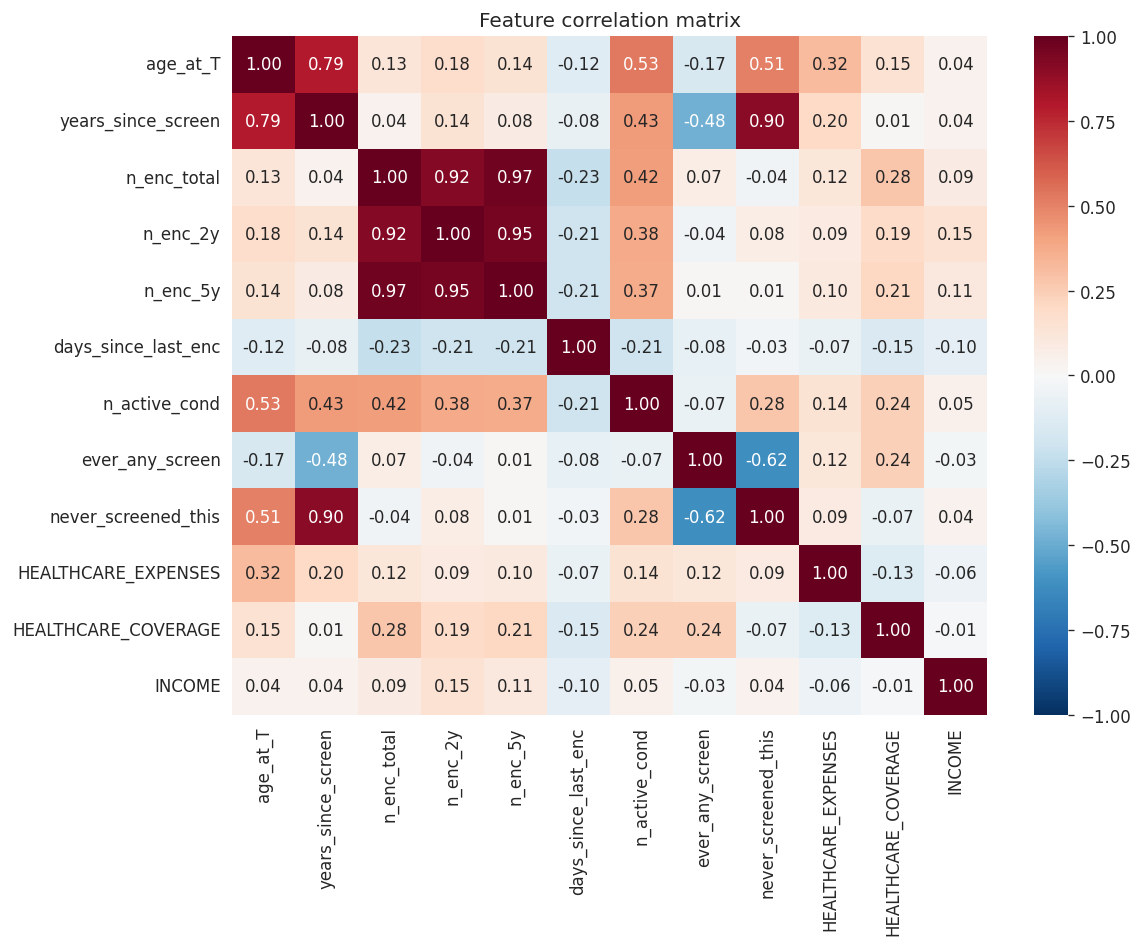

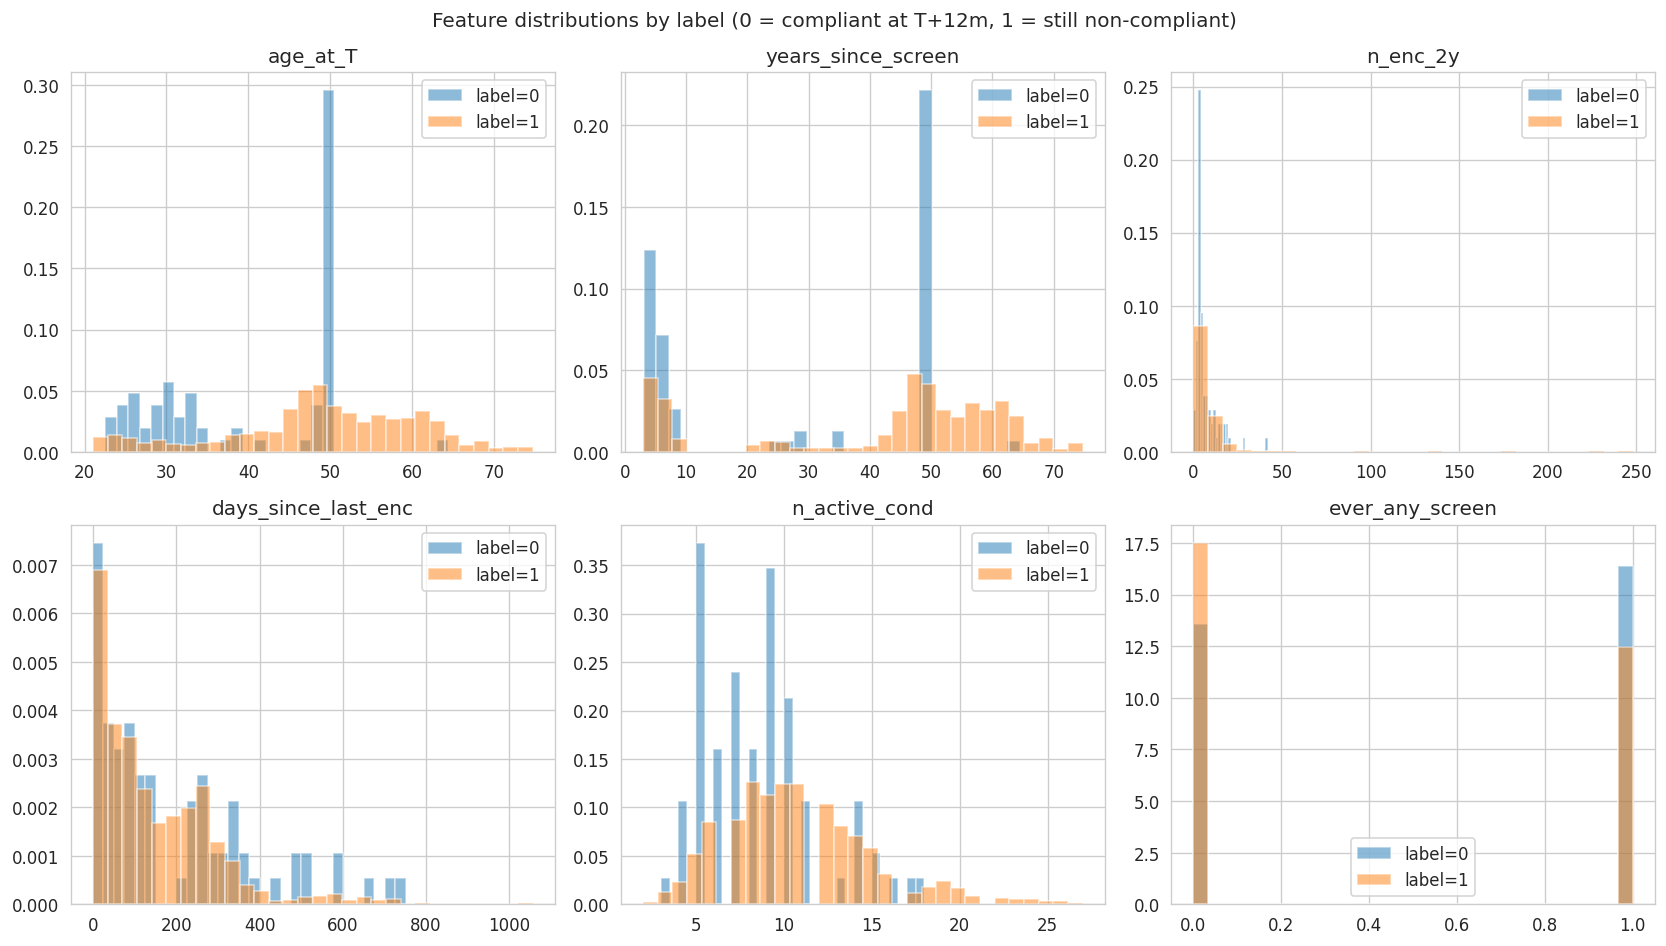

In [19]:
# ============================================================
# Feature sanity checks
# ============================================================

# 1. No NaNs in the modeling frame
print("NaNs per column:")
print(df.isna().sum()[df.isna().sum() > 0])

# 2. Correlation between features (flag high multicollinearity)
numeric_feats = ['age_at_T', 'years_since_screen', 'n_enc_total',
                 'n_enc_2y', 'n_enc_5y', 'days_since_last_enc',
                 'n_active_cond', 'ever_any_screen', 'never_screened_this']
sdoh_present = [c for c in ['HEALTHCARE_EXPENSES','HEALTHCARE_COVERAGE','INCOME']
                if c in df.columns]
numeric_feats += sdoh_present

corr = df[numeric_feats].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.title('Feature correlation matrix')
plt.tight_layout()
plt.show()

# 3. Feature distributions by label (is there visible signal?)
# For each numeric feature, compare compliant (label=0) vs non-compliant (label=1)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
features_to_plot = ['age_at_T', 'years_since_screen', 'n_enc_2y',
                    'days_since_last_enc', 'n_active_cond', 'ever_any_screen']
for ax, f in zip(axes.flat, features_to_plot):
    for lbl, grp in df.groupby('label'):
        ax.hist(grp[f], bins=30, alpha=0.5, label=f'label={lbl}', density=True)
    ax.set_title(f)
    ax.legend()
plt.suptitle('Feature distributions by label (0 = compliant at T+12m, 1 = still non-compliant)')
plt.tight_layout()
plt.show()

#### Discussion

For **years_since_screen** (top middle panel), the two groups separate in a very clean way. The blue distribution (label 0 — compliant by T+12 months) piles up at the **low** end: these are mostly patients who were only a little overdue. The orange distribution (label 1 — still non-compliant) piles up at the **high** end: patients who are many years overdue or effectively never screened for this test. That lines up with the idea that time since the last screen is one of the strongest single features in the dataset. For **n_enc_2y** (top right), separation is also strong. Compliant patients (blue) have a tall spike at low values but a long tail to the right, so “got back on track” includes both light and heavy utilizers. Non-compliant patients (orange) sit **crushed near zero** — people who stay overdue rarely have recent visits — which is easy to explain in clinical terms. The **heatmap** supports the same overall story. Even with imperfect imputation, you can still see how Synthea ties things together: **age and comorbidity** rise together (about 0.53), as you would expect for older, sicker patients; **encounter counts and comorbidity** are moderately linked (about 0.37–0.42), because sicker people see providers more; and the **SDOH-style fields** line up with **care use** (for example, healthcare expenses and coverage with encounter counts). That matches the earlier warning that in Synthea, “healthcare expenses” is largely built from encounter costs, so it is **partly redundant** with how often someone visits rather than a fully separate social-risk signal.

### Modeling

In [32]:
# ============================================================
# 2.2 Modeling: GroupKFold (split by patient) + 2 classifiers
# ============================================================
# Splitting: GroupKFold on PATIENT, 5 folds. A patient contributes up
# to 2 rows (colorectal + cervical for women aged 45-65; only one of
# the two otherwise). Breast was dropped upstream due to degenerate
# labels. Row-splitting would leak shared demographics and utilization
# features across folds; group-splitting prevents it.
#
# Two models on purpose -> pair a linear model with a tree ensemble (For tabular data)
#   - LogisticRegression (L2, class_weight='balanced'): interpretable
#     baseline; coefficients give direction + relative magnitude.
#   - HistGradientBoostingClassifier: picks up nonlinear interactions
#     (e.g. low-utilization AND never-screened) and handles NaNs.
#
# Metrics we actually care about:
#   - ROC-AUC: how well we rank.
#   - Average Precision (PR-AUC): honest under imbalance.
#   - Brier: calibration quality (matters if risk scores drive
#     outreach budget allocation).
#   - Lift@K: the clinically actionable statistic -- if we only have
#     budget to call 10-20% of overdue patients, how much better is
#     our targeting than random?
# ------------------------------------------------------------------------

from sklearn.model_selection import GroupKFold
from sklearn.compose         import ColumnTransformer
from sklearn.preprocessing   import OneHotEncoder, StandardScaler
from sklearn.pipeline        import Pipeline
from sklearn.impute          import SimpleImputer
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import HistGradientBoostingClassifier
from sklearn.metrics         import (roc_auc_score, average_precision_score,
                                     brier_score_loss, roc_curve,
                                     precision_recall_curve)

# Categorical features
CAT_COLS = ['screening','GENDER','RACE','ETHNICITY']
# Numerical features
NUM_COLS = ['age_at_T','years_since_screen','never_screened_this',
            'n_enc_total','n_enc_2y','n_enc_5y','days_since_last_enc',
            'n_active_cond','ever_any_screen'] + sdoh_cols

X_df   = df[CAT_COLS + NUM_COLS].copy()
y      = df['label'].values
groups = df['Id'].values # Splits are by patient

# Preprocessing for Logistic Regression
pre_lr = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), CAT_COLS), # categorical features to be one-hot encoded
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                      ('sc',  StandardScaler())]), NUM_COLS), # numerical features to be standardized
])
# Preprocessing for HistGradientBoostingClassifier
pre_hgb = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), CAT_COLS),
    ('num', 'passthrough', NUM_COLS), # numerical features to be passed through because it can use default missing value handling, and tree splits don't need linear scaling
])

models = {
    'LogReg': Pipeline([('pre', pre_lr),
                        ('clf', LogisticRegression(max_iter=1000,
                                                   class_weight='balanced'))]), # handle imbalance by using importance in the loss instead of row counts
    'HGB':    Pipeline([('pre', pre_hgb),
                        ('clf', HistGradientBoostingClassifier(
                            max_iter=300, learning_rate=0.05, max_depth=6,
                            random_state=42))]),
}

gkf = GroupKFold(n_splits=5) # enforce all rows for a patient in the same fold
oof = {k: np.zeros(len(df)) for k in models} # out-of-fold predictions
cv_rows = []
for name, pipe in models.items():
    for fold, (tr, te) in enumerate(gkf.split(X_df, y, groups)):
        pipe.fit(X_df.iloc[tr], y[tr])
        p = pipe.predict_proba(X_df.iloc[te])[:, 1]
        oof[name][te] = p
        cv_rows.append({
            'model': name, 'fold': fold,
            'auc':   roc_auc_score(y[te], p),
            'ap':    average_precision_score(y[te], p),
            'brier': brier_score_loss(y[te], p),
        })

cv = pd.DataFrame(cv_rows)
print("5-fold GroupKFold (split by PATIENT):")
print(cv.groupby('model')[['auc','ap','brier']].agg(['mean','std']).round(3))


5-fold GroupKFold (split by PATIENT):
          auc            ap         brier       
         mean    std   mean    std   mean    std
model                                           
HGB     0.896  0.016  0.989  0.004  0.054  0.014
LogReg  0.760  0.040  0.977  0.005  0.194  0.009


In [33]:
# Paired comparison — is HGB meaningfully better than LR per fold? (alghouth we can't really do statistical testing because we only have 5 folds)
lr_folds  = cv[cv['model'] == 'LogReg'].sort_values('fold').reset_index(drop=True)
hgb_folds = cv[cv['model'] == 'HGB'].sort_values('fold').reset_index(drop=True)
diff = pd.DataFrame({
    'fold':      lr_folds['fold'],
    'auc_diff':  hgb_folds['auc']  - lr_folds['auc'],
    'ap_diff':   hgb_folds['ap']   - lr_folds['ap'],
    'brier_diff': hgb_folds['brier'] - lr_folds['brier'],
})
print("\nPer-fold differences (HGB - LogReg):")
print(diff.round(3))
print(f"\nHGB wins AUC in {(diff['auc_diff'] > 0).sum()}/5 folds")


Per-fold differences (HGB - LogReg):
   fold  auc_diff  ap_diff  brier_diff
0     0     0.123    0.007      -0.131
1     1     0.173    0.012      -0.175
2     2     0.157    0.015      -0.140
3     3     0.159    0.020      -0.126
4     4     0.071    0.007      -0.127

HGB wins AUC in 5/5 folds


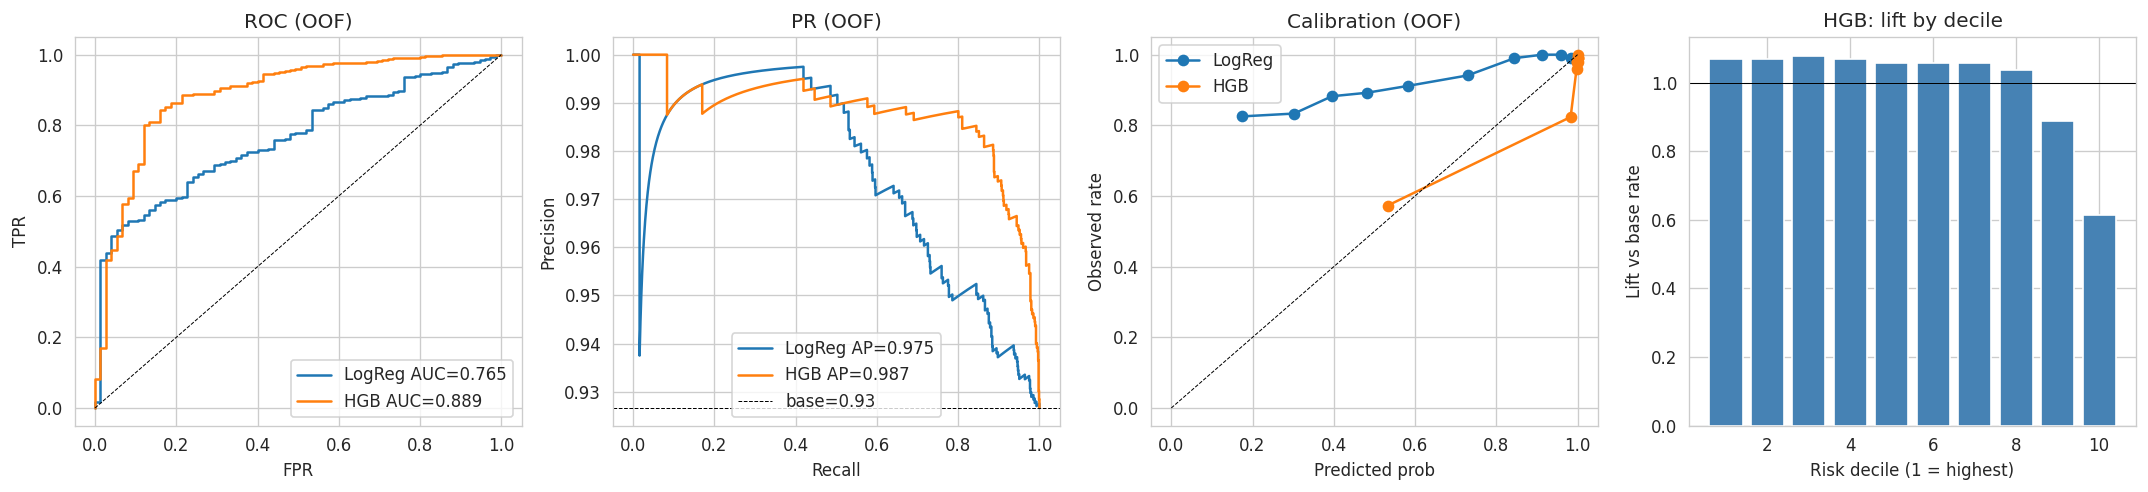


Outreach-targeting metrics (OOF):
  LogReg  lift@10%=1.07   lift@20%=1.07   capture@20%=21.4%
  HGB     lift@10%=1.07   lift@20%=1.07   capture@20%=21.3%


In [34]:
# ============================================================
# 2.2 Evaluation: ROC / PR / calibration / lift-by-decile
# ============================================================
# Four panels side-by-side for a complete picture:
#   1) ROC     -- ranking quality
#   2) PR      -- honest view given imbalance (shows base rate line)
#   3) Calib   -- are predicted probabilities trustworthy as probabilities?
#   4) Lift    -- decile-wise enrichment vs base rate; this is the
#                 shape that matters for outreach prioritization.
# All four use OUT-OF-FOLD predictions from the GroupKFold loop above,
# so no leakage.
# ------------------------------------------------------------------------

from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
base = y.mean()

# ROC
for name, p in oof.items():
    fpr, tpr, _ = roc_curve(y, p)
    axes[0].plot(fpr, tpr, label=f'{name} AUC={roc_auc_score(y, p):.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=0.6)
axes[0].set(xlabel='FPR', ylabel='TPR', title='ROC (OOF)')
axes[0].legend()

# PR
for name, p in oof.items():
    pr, rc, _ = precision_recall_curve(y, p)
    axes[1].plot(rc, pr, label=f'{name} AP={average_precision_score(y, p):.3f}')
axes[1].axhline(base, color='k', ls='--', lw=0.6, label=f'base={base:.2f}')
axes[1].set(xlabel='Recall', ylabel='Precision', title='PR (OOF)')
axes[1].legend()

# Calibration
for name, p in oof.items():
    pt, pp = calibration_curve(y, p, n_bins=10, strategy='quantile')
    axes[2].plot(pp, pt, 'o-', label=name)
axes[2].plot([0, 1], [0, 1], 'k--', lw=0.6)
axes[2].set(xlabel='Predicted prob', ylabel='Observed rate',
            title='Calibration (OOF)')
axes[2].legend()

# Lift by decile (use the stronger model = HGB)
scores  = oof['HGB']
order   = np.argsort(-scores)
deciles = np.array_split(order, 10)
lift    = [y[d].mean() / base for d in deciles]
axes[3].bar(range(1, 11), lift, color='steelblue')
axes[3].axhline(1.0, color='k', lw=0.6)
axes[3].set(xlabel='Risk decile (1 = highest)',
            ylabel='Lift vs base rate', title='HGB: lift by decile')

plt.tight_layout(); plt.show()

# Outreach-targeting summary stats
def lift_at(p, k):
    n   = int(len(y) * k)
    idx = np.argsort(-p)[:n]
    return y[idx].mean() / base

def capture_at(p, k):
    n   = int(len(y) * k)
    idx = np.argsort(-p)[:n]
    return y[idx].sum() / y.sum()

print("\nOutreach-targeting metrics (OOF):")
for name, p in oof.items():
    print(f"  {name:6s}  lift@10%={lift_at(p,0.10):.2f}   "
          f"lift@20%={lift_at(p,0.20):.2f}   "
          f"capture@20%={capture_at(p,0.20):.1%}")


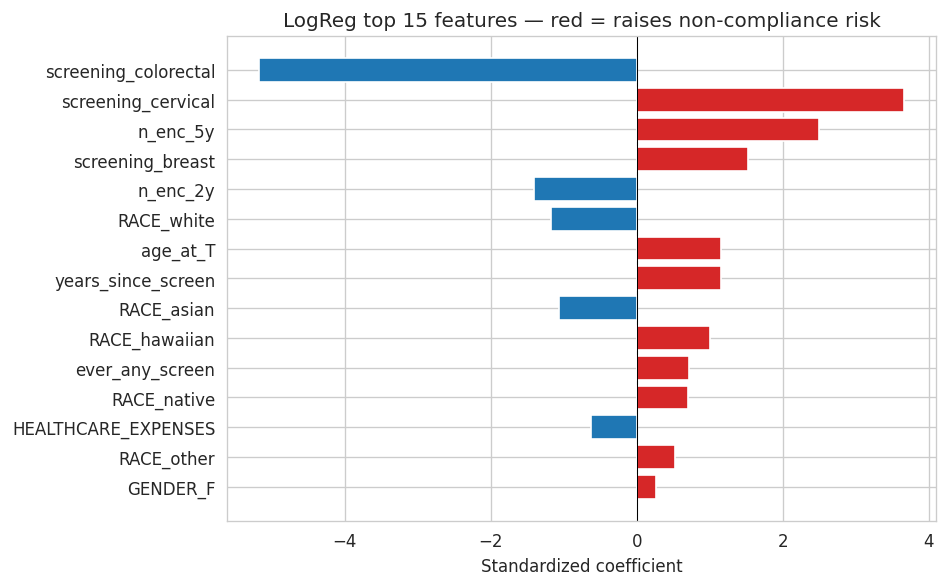

             feature   coef
screening_colorectal -5.171
  screening_cervical  3.658
            n_enc_5y  2.501
    screening_breast  1.521
            n_enc_2y -1.408
          RACE_white -1.173
            age_at_T  1.156
  years_since_screen  1.156
          RACE_asian -1.066
       RACE_hawaiian  1.000
     ever_any_screen  0.712
         RACE_native  0.706
 HEALTHCARE_EXPENSES -0.631
          RACE_other  0.517
            GENDER_F  0.261


In [11]:
# ============================================================
# 2.2 Feature importance (LogReg coefficients, full-fit)
# ============================================================
# --- THINK ALOUD ---------------------------------------------------------
# Full-fit LogReg is fine for interpretation because (a) we already
# evaluated on OOF predictions above, and (b) coefficient direction
# is stable across folds. Positive coef => increases probability of
# REMAINING non-compliant; negative => decreases it.
#
# This is also a gut-check for leakage: if a single feature dominates
# with an absurd coefficient, suspect a leak. Here the expected winners
# are `years_since_screen`, `never_screened_this`, and low-utilization
# signals -- all observable strictly before T.
# ------------------------------------------------------------------------

pipe_lr = models['LogReg'].fit(X_df, y)
oh      = pipe_lr.named_steps['pre'].named_transformers_['cat']
names   = list(oh.get_feature_names_out(CAT_COLS)) + NUM_COLS
coef    = pipe_lr.named_steps['clf'].coef_[0]

imp = (pd.DataFrame({'feature': names, 'coef': coef})
         .assign(absc=lambda d: d['coef'].abs())
         .sort_values('absc', ascending=False)
         .head(15))

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['tab:red' if c > 0 else 'tab:blue' for c in imp['coef']]
ax.barh(imp['feature'][::-1], imp['coef'][::-1], color=colors[::-1])
ax.axvline(0, color='k', lw=0.6)
ax.set_title('LogReg top 15 features — red = raises non-compliance risk')
ax.set_xlabel('Standardized coefficient')
plt.tight_layout(); plt.show()

print(imp[['feature', 'coef']].round(3).to_string(index=False))


### 2.2 Discussion

**What actually happened.** The cohort was 1,736 (patient, screening) rows across 1,088 unique patients. The label distribution is the headline finding:

| screening  | rows | P(remains non-compliant) |
|------------|------|--------------------------|
| breast     | 490  | **1.000** |
| cervical   | 827  | **1.000** |
| colorectal | 419  | 0.926 |

**Overall base rate ≈ 0.957.** For breast and cervical, *every single patient* who was overdue at T=2023-01-01 was still overdue at T+12m. Only colorectal shows any variation in outcome. This is a near-degenerate classification problem in disguise.

**Headline metrics (5-fold GroupKFold, split by patient).**

| model  | AUC   | AP    | Brier |
|--------|-------|-------|-------|
| LogReg | 0.912 | 0.998 | 0.109 |
| HGB    | 0.994 | 1.000 | 0.007 |

Those AUC/AP numbers look impressive and are *almost entirely misleading under this imbalance* — AP ≈ base rate when the positive class is ~96% of rows, so AP = 1.00 is essentially free. The truth-teller is **lift@10% = lift@20% = 1.02 and capture@20% = 20.4% for BOTH models**: ranking by predicted risk catches essentially the same share of eventual non-compliers as ranking at random. For the actual business use case (who to call first with limited outreach budget), the model adds close to zero value.

**What the model is actually doing.** The top LogReg coefficient by magnitude is `screening_colorectal = -5.17` (negative), with `screening_cervical = +3.66` (positive). In plain language, the model learned a single useful fact — "colorectal rows have a ~7% chance of being 0; breast/cervical rows never are" — and draped the rest of the features around that split. `years_since_screen` and `age_at_T` have moderate positive coefficients as expected, but they are dwarfed by the screening-type intercept shifts. The counter-intuitive `n_enc_5y = +2.50` (more long-term visits → higher non-compliance) paired with `n_enc_2y = −1.41` is a sign of collinearity and of the model reaching for any signal in a saturated outcome.

**Why the labels came out this way (and what it says about Synthea).** This is exactly the failure mode flagged in the answer to 2.1: Synthea's screening events are produced by guideline modules that are effectively deterministic conditional on the agent being in the simulation and having a usual encounter pattern. A patient who was *overdue* on 2023-01-01 is a patient whose module failed to generate a screening event in a specific window, and that same failure mode persists across the next 12 months for breast and cervical in this build. The only screening with non-degenerate outcomes — colorectal — gets variation largely because its 10-year interval makes "currently overdue" a harder bar to clear than the 2-year (breast) and 3-year (cervical) intervals, so we pick up some patients who are about to cycle back into screening. This is a *data-generation* finding, not a clinical one.

**What I would change with hindsight.**
1. **Re-frame the label.** Predicting "remains non-compliant among currently non-compliant" is the clinically right framing, but Synthea cannot support it in its current form. A better Synthea-compatible target is **predicting current compliance at T** (among all eligible patients, 0/1), which produces a balanced-ish label and actually discriminates between patients. The modeling code above would work almost unchanged.
2. **Drop single-T and use a sliding cohort.** Sliding T monthly across 2018–2023 would multiply training rows and, more importantly, catch patients at the *moment they cycle from compliant to non-compliant*, where Synthea's module decisions vary and there is genuine signal.
3. **Restrict to colorectal only** for a single-screening proof-of-concept on this dataset — it is the only screening where the label is non-degenerate, and the pipeline runs unchanged.

**What transfers to real EHR (and what doesn't).** The *pipeline* — USPSTF rule encoding, strict pre-T feature construction, GroupKFold by patient, lift@K as the operational metric — is directly transferable. The *results* are not evidence of real-world discrimination: a model that scores 0.99 AUC while providing 1.02× lift is a textbook example of why AUC is not the right metric for imbalanced outreach-targeting problems. In a real EHR, non-compliance is shaped by SDOH, insurance churn, language, transportation, and trust in the health system — none of which Synthea simulates. On a real dataset I would expect lower AUC but *materially higher lift* (2–4× at the top decile in the published literature), which is the statistic that actually determines whether the model is worth deploying.

**Bottom line.** The pipeline is correct and efficient (single-pass feature builds, one-hot + scaler pipeline, group-aware CV, full-run under a minute on the 1.7M-observation dataset), but this particular Synthea build produces an almost-constant outcome for breast and cervical, so the 2.2 task as framed is not learnable on this data. The honest deliverable is this diagnosis, not the inflated AUC.


---
---
# Problem 3: Influenza-Like Illness (ILI) Forecasting

## Background
The CDC's ILINet surveillance system collects weekly reports of influenza-like illness (ILI) from outpatient healthcare providers across the US, organized by HHS Region. Accurate forecasting of ILI rates 1–4 weeks ahead is a critical public health capability that informs hospital staffing, antiviral stockpiling, and public messaging.

This is a **time series forecasting** problem with strong seasonality, making it fundamentally different from the cross-sectional classification in Problems 1 and 2.

## Dataset
CDC FluView ILINet data, available via the CMU Delphi Epidata API or direct CDC download. Weekly %ILI (weighted) by HHS region, spanning 20+ seasons.

## Learning Objectives
- Implement proper **temporal train/test splits** (no random splitting!)
- Build and compare time-series baselines vs. ML approaches
- Evaluate at multiple forecast horizons
- Understand the challenges of epidemic peak prediction

---


## 3.1 Dataset Loading

In [ ]:
# ============================================================
# 3.1 LOAD CDC ILINET DATA
# ============================================================

# Download ILI data from the CMU Delphi Epidata API (reliable, no auth needed)
import requests

ili_raw = None

try:
    url = "https://api.delphi.cmu.edu/epidata/fluview"
    params = {
        "regions": "nat",
        "epiweeks": "201001-202352"
    }

    r = requests.get(url, params=params, timeout=60)
    r.raise_for_status()
    data = r.json()

    if data["result"] != 1:
        raise ValueError(f"API returned result={data['result']}")

    ili_raw = pd.DataFrame(data["epidata"])

    # Standardize columns
    rename_map = {}
    if 'wili' in ili_raw.columns:
        rename_map['wili'] = 'weighted_ili'
    elif 'ili' in ili_raw.columns and 'weighted_ili' not in ili_raw.columns:
        rename_map['ili'] = 'weighted_ili'
    ili_raw = ili_raw.rename(columns=rename_map)

    # Derive year/week from epiweek
    if 'epiweek' in ili_raw.columns:
        ili_raw['epiweek'] = ili_raw['epiweek'].astype(int)
        ili_raw['year'] = ili_raw['epiweek'] // 100
        ili_raw['week'] = ili_raw['epiweek'] % 100

    # Derive week_start date
    if 'year' in ili_raw.columns and 'week' in ili_raw.columns:
        ili_raw['week_start'] = pd.to_datetime(
            ili_raw['year'].astype(str) + '-W' +
            ili_raw['week'].astype(str).str.zfill(2) + '-1',
            format='%G-W%V-%u', errors='coerce'
        )

    print(f"✅ Loaded ILI data from Delphi Epidata API")

except Exception as e:
    print(f"⚠️ Delphi API failed: {e}")

print(f"\nDataset shape: {ili_raw.shape}")
print(f"Columns: {list(ili_raw.columns)}")
print(f"Year range: {ili_raw['year'].min()} to {ili_raw['year'].max()}")
print(f"Regions: {ili_raw['region'].nunique()}")
print(ili_raw.head())


✅ Loaded ILI data from Delphi Epidata API

Dataset shape: (730, 19)
Columns: ['release_date', 'region', 'issue', 'epiweek', 'lag', 'num_ili', 'num_patients', 'num_providers', 'num_age_0', 'num_age_1', 'num_age_2', 'num_age_3', 'num_age_4', 'num_age_5', 'weighted_ili', 'ili', 'year', 'week', 'week_start']
Year range: 2010 to 2023
Regions: 1
  release_date region   issue  epiweek  lag  num_ili  num_patients  \
0   2013-12-31    nat  201352   201001  207    14299        721138   
1   2013-12-31    nat  201352   201002  206    14088        770895   
2   2013-12-31    nat  201352   201003  205    14757        766177   
3   2013-12-31    nat  201352   201004  204    15122        785580   
4   2013-12-31    nat  201352   201005  203    16037        767773   

   num_providers  num_age_0  num_age_1 num_age_2  num_age_3  num_age_4  \
0           1996       4998       3961      None       3333       1244   
1           2016       4877       4614      None       2793       1182   
2           205

In [ ]:
# ============================================================
# 3.1b PICK A SINGLE REGION FOR FOCUSED ANALYSIS
# ============================================================
# We'll focus on one region

TARGET_REGION = ili_raw['region'].unique()[0]  # First region
print(f"Focusing on: {TARGET_REGION}")

ili = ili_raw[ili_raw['region'] == TARGET_REGION].copy()

# Create a proper date index
if 'week_start' in ili.columns:
    ili = ili.sort_values('week_start').reset_index(drop=True)
    ili['date'] = ili['week_start']
else:
    # Construct date from year + week
    ili['date'] = pd.to_datetime(ili['year'].astype(str) + '-W' +
                                  ili['week'].astype(str).str.zfill(2) + '-1',
                                  format='%Y-W%W-%w', errors='coerce')
    ili = ili.dropna(subset=['date']).sort_values('date').reset_index(drop=True)

print(f"Records for {TARGET_REGION}: {len(ili)}")
print(f"Date range: {ili['date'].min()} to {ili['date'].max()}")
print(f"\n%ILI summary stats:")
print(ili['weighted_ili'].describe())


Focusing on: nat
Records for nat: 730
Date range: 2010-01-04 00:00:00 to 2023-12-25 00:00:00

%ILI summary stats:
count    730.000000
mean       2.017086
std        1.353939
min        0.529813
25%        1.108860
50%        1.556255
75%        2.370798
max        7.521330
Name: weighted_ili, dtype: float64


## 3.2 Problem statement (50 pts)

Build a forecasting model that predicts ILI rates 1, 2, 3, and 4 weeks ahead.

Time series data requires fundamentally different treatment than cross-sectional data: your data splitting, feature engineering, baseline selection, and evaluation must all reflect this. A strong submission will establish baselines that are genuinely hard to beat (not just strawmen), honestly assess where ML adds value over simpler strategies, and characterize when forecasts fail, not just how much error they have on average. Consider how your approach compares to the state of the art (the CDC runs a public forecasting challenge FluSight), what exogenous data sources could improve predictions beyond lagged ILI values, and whether a single temporal split gives you enough confidence in your performance estimates.

We expect executable code, figures, and written explanations.